# Estimation de la valeur des biens immobiliers résidentiels au Sénégal
## 2. Modélisation, optimisation des hyperparamètres et comparaison des modèles

Mémoire M1 — Dakar Institute of Technology (DIT)

Ce notebook correspond aux sections **4. Méthodologie** (choix des algorithmes, optimisation) et **5.2 Résultats des modèles** du plan DIT. Il :
1. charge le dataset nettoyé (`data/processed/expat_dakar_listings_clean.csv`),
2. prépare les features (encodage, regroupement des quartiers rares),
3. entraîne et **optimise les hyperparamètres** de 3 modèles (Random Forest, XGBoost, réseau de neurones MLP) par recherche aléatoire avec validation croisée, en comparaison avec une régression linéaire de référence,
4. compare les performances (RMSE, MAE, MAPE, R²),
5. sauvegarde les modèles entraînés pour l'interface Streamlit (notebook/app suivant).

**Compatible Google Colab** : chargement des données avec repli sur upload manuel si nécessaire.


In [1]:
%pip install -q xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\snbam\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## Chargement des données nettoyées


In [3]:
CANDIDATE_PATHS = [
    "data/processed/expat_dakar_listings_clean.csv",
    "../data/processed/expat_dakar_listings_clean.csv",
    "expat_dakar_listings_clean.csv",
]

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

data_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if data_path is None and IN_COLAB:
    from google.colab import files
    print("Fichier introuvable dans la session Colab. Uploadez expat_dakar_listings_clean.csv :")
    uploaded = files.upload()
    data_path = next(iter(uploaded.keys()))

if data_path is None:
    raise FileNotFoundError(
        "expat_dakar_listings_clean.csv introuvable. Exécutez d'abord le notebook "
        "01_eda_nettoyage.ipynb, ou uploadez le fichier quand demandé (Colab)."
    )

df = pd.read_csv(data_path)
print(f"{len(df)} lignes chargées depuis {data_path}")
df.head()


603 lignes chargées depuis ../data/processed/expat_dakar_listings_clean.csv


,listing_id,title,category,price_fcfa,currency,neighborhood,city_region,bedrooms,surface_m2,date_posted_raw,url
0,6706003,Villa R+2 à vendre aux Almadies Titre Foncier,Maisons à vendre,330000000.0,XOF,Almadies,Dakar,5.0,314.0,"Aujourd'hui, 17:24",https://www.expat-dakar.com/annonce/villa-r2-a...
1,6827403,Votre futur logement écologique à Bambilor,Maisons à vendre,40000000.0,XOF,Bambilor,Dakar,3.0,250.0,"Aujourd'hui, 12:25",https://www.expat-dakar.com/annonce/votre-futu...
2,6736189,Villa à vendre R+3 à Sicap Keur Massar,Maisons à vendre,160000000.0,XOF,Keur Massar,Dakar,5.0,250.0,"26. mai, 15:10",https://www.expat-dakar.com/annonce/villa-a-ve...
3,6827681,Maison à Vendre aux Parcelles Assainies Unité 11,Maisons à vendre,60000000.0,XOF,Parcelles Assainies,Dakar,7.0,200.0,"Aujourd'hui, 20:08",https://www.expat-dakar.com/annonce/maison-a-v...
4,6827149,Villa à vendre cité ALIOU SOW,Maisons à vendre,120000000.0,XOF,Golf,Dakar,3.0,150.0,"Hier, 22:04",https://www.expat-dakar.com/annonce/villa-a-ve...


## Préparation des features

- **Numériques** : `surface_m2`, `bedrooms`.
- **Catégorielles** : `category` (Maison / Appartement), `neighborhood` — regroupé : les quartiers avec moins de 5 annonces sont fusionnés dans une catégorie `Autre` pour éviter le surapprentissage (92 quartiers uniques pour 609 lignes, dont beaucoup avec 1 seule annonce).
- `city_region` est exclue des features : elle est presque entièrement déterminée par le quartier (redondance/colinéarité), qui est une variable de localisation plus précise.
- **Cible** : `price_fcfa`, transformée en `log1p(price)` pour l'entraînement (distribution très asymétrique — cf. notebook 1), puis les prédictions sont retransformées en FCFA (`expm1`) pour le calcul des métriques finales, plus interprétables pour le rapport.


In [4]:
MIN_NEIGHBORHOOD_COUNT = 5

neighborhood_counts = df["neighborhood"].value_counts()
frequent_neighborhoods = neighborhood_counts[neighborhood_counts >= MIN_NEIGHBORHOOD_COUNT].index.tolist()

df["neighborhood_grouped"] = df["neighborhood"].where(
    df["neighborhood"].isin(frequent_neighborhoods), other="Autre"
)

print(f"{len(frequent_neighborhoods)} quartiers conservés tels quels + 1 catégorie 'Autre'")
print(f"Nouvelle cardinalité neighborhood_grouped : {df['neighborhood_grouped'].nunique()}")

NUMERIC_FEATURES = ["surface_m2", "bedrooms"]
CATEGORICAL_FEATURES = ["category", "neighborhood_grouped"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "price_fcfa"

X = df[FEATURES].copy()
y_log = np.log1p(df[TARGET])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)
y_test_fcfa = np.expm1(y_test_log)

print(f"Train: {X_train.shape[0]} lignes | Test: {X_test.shape[0]} lignes")


33 quartiers conservés tels quels + 1 catégorie 'Autre'
Nouvelle cardinalité neighborhood_grouped : 34
Train: 482 lignes | Test: 121 lignes


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)


## Fonctions d'évaluation

Métriques calculées en FCFA (après retransformation `expm1`), plus interprétables que le RMSE/MAE en espace log pour la discussion dans le rapport :

- **RMSE** (Root Mean Squared Error) : pénalise fortement les grosses erreurs.
- **MAE** (Mean Absolute Error) : erreur moyenne absolue, en FCFA.
- **MAPE** (Mean Absolute Percentage Error) : erreur moyenne en %, la plus parlante pour un jury ("le modèle se trompe en moyenne de X %").
- **R²** : part de variance expliquée.


In [6]:
results = {}

def evaluate_model(name, pipeline, X_test, y_test_log):
    y_pred_log = pipeline.predict(X_test)
    y_pred_fcfa = np.expm1(y_pred_log)
    y_true_fcfa = np.expm1(y_test_log)

    rmse = np.sqrt(mean_squared_error(y_true_fcfa, y_pred_fcfa))
    mae = mean_absolute_error(y_true_fcfa, y_pred_fcfa)
    mape = np.mean(np.abs((y_true_fcfa - y_pred_fcfa) / y_true_fcfa)) * 100
    r2 = r2_score(y_true_fcfa, y_pred_fcfa)

    results[name] = {"RMSE_FCFA": rmse, "MAE_FCFA": mae, "MAPE_%": mape, "R2": r2}
    print(f"{name} -> RMSE: {rmse:,.0f} FCFA | MAE: {mae:,.0f} FCFA | MAPE: {mape:.1f}% | R2: {r2:.3f}")
    return y_pred_fcfa


## Modèle 1 — Régression linéaire (référence, sans optimisation)

Sert de ligne de base simple pour juger si les modèles plus complexes (et leur optimisation) apportent un réel gain.


In [7]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])
lr_pipeline.fit(X_train, y_train_log)
_ = evaluate_model("Régression linéaire", lr_pipeline, X_test, y_test_log)


Régression linéaire -> RMSE: 148,156,086 FCFA | MAE: 89,002,102 FCFA | MAPE: 39.7% | R2: 0.571


## Modèle 2 — Random Forest (optimisé)

Optimisation par `RandomizedSearchCV` (recherche aléatoire, 30 combinaisons, validation croisée 5-fold) sur les hyperparamètres clés : nombre d'arbres, profondeur, taille min. des feuilles/splits, nombre de features considérées à chaque split.


In [8]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE)),
])

rf_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [None, 5, 10, 15, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=30,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)

print("Meilleurs hyperparamètres Random Forest :", rf_search.best_params_)
rf_best = rf_search.best_estimator_
_ = evaluate_model("Random Forest (optimisé)", rf_best, X_test, y_test_log)


Meilleurs hyperparamètres Random Forest : {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30}
Random Forest (optimisé) -> RMSE: 112,897,339 FCFA | MAE: 73,325,765 FCFA | MAPE: 34.0% | R2: 0.751


## Modèle 3 — XGBoost (optimisé)

Même protocole d'optimisation, sur le taux d'apprentissage, la profondeur, le sous-échantillonnage et la régularisation.


In [9]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=RANDOM_STATE, objective="reg:squarederror")),
])

xgb_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 1.5, 2],
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=30,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train_log)

print("Meilleurs hyperparamètres XGBoost :", xgb_search.best_params_)
xgb_best = xgb_search.best_estimator_
_ = evaluate_model("XGBoost (optimisé)", xgb_best, X_test, y_test_log)


Meilleurs hyperparamètres XGBoost : {'model__subsample': 1.0, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.6}
XGBoost (optimisé) -> RMSE: 125,455,687 FCFA | MAE: 79,242,132 FCFA | MAPE: 37.7% | R2: 0.692


## Modèle 4 — Réseau de neurones (MLP, optimisé)

**Choix d'implémentation** : `MLPRegressor` de scikit-learn plutôt que TensorFlow/Keras. Avec ~600 lignes d'entraînement, un framework de deep learning complet (GPU, callbacks, etc.) n'apporte rien : un perceptron multicouche reste le bon niveau de complexité pour ce volume de données, tout en permettant une vraie optimisation d'hyperparamètres (architecture, régularisation, taux d'apprentissage) — l'objectif visé par le sujet du mémoire.


In [10]:
mlp_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        random_state=RANDOM_STATE,
        max_iter=3000,
        early_stopping=True,
        n_iter_no_change=20,
    )),
])

mlp_param_distributions = {
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64), (64, 64, 32)],
    "model__alpha": [0.0001, 0.001, 0.01, 0.1],
    "model__learning_rate_init": [0.0005, 0.001, 0.005, 0.01],
    "model__activation": ["relu", "tanh"],
}

mlp_search = RandomizedSearchCV(
    mlp_pipeline,
    param_distributions=mlp_param_distributions,
    n_iter=30,
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
mlp_search.fit(X_train, y_train_log)

print("Meilleurs hyperparamètres MLP :", mlp_search.best_params_)
mlp_best = mlp_search.best_estimator_
_ = evaluate_model("MLP (optimisé)", mlp_best, X_test, y_test_log)


Meilleurs hyperparamètres MLP : {'model__learning_rate_init': 0.005, 'model__hidden_layer_sizes': (32,), 'model__alpha': 0.1, 'model__activation': 'tanh'}
MLP (optimisé) -> RMSE: 125,968,083 FCFA | MAE: 82,416,154 FCFA | MAPE: 37.0% | R2: 0.690


## Comparaison des modèles


In [11]:
results_df = pd.DataFrame(results).T.sort_values("MAE_FCFA")
results_df


,RMSE_FCFA,MAE_FCFA,MAPE_%,R2
Random Forest (optimisé),1.128973e+08,7.332576e+07,34.042996,0.750876
XGBoost (optimisé),1.254557e+08,7.924213e+07,37.732383,0.692370
MLP (optimisé),1.259681e+08,8.241615e+07,37.019530,0.689852
Régression linéaire,1.481561e+08,8.900210e+07,39.681532,0.570970


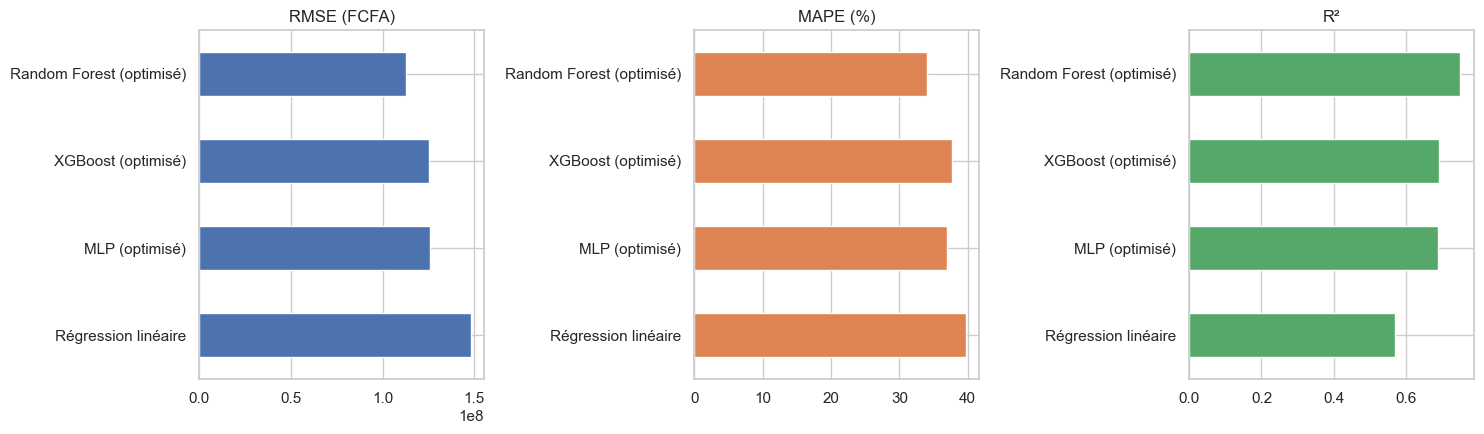

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

results_df["RMSE_FCFA"].plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("RMSE (FCFA)")
axes[0].invert_yaxis()

results_df["MAPE_%"].plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("MAPE (%)")
axes[1].invert_yaxis()

results_df["R2"].plot(kind="barh", ax=axes[2], color="#55A868")
axes[2].set_title("R²")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


## Importance des variables (Random Forest / XGBoost)

Utile pour la section "Interprétation des résultats" du rapport : quelles variables pèsent le plus dans la prédiction du prix ?


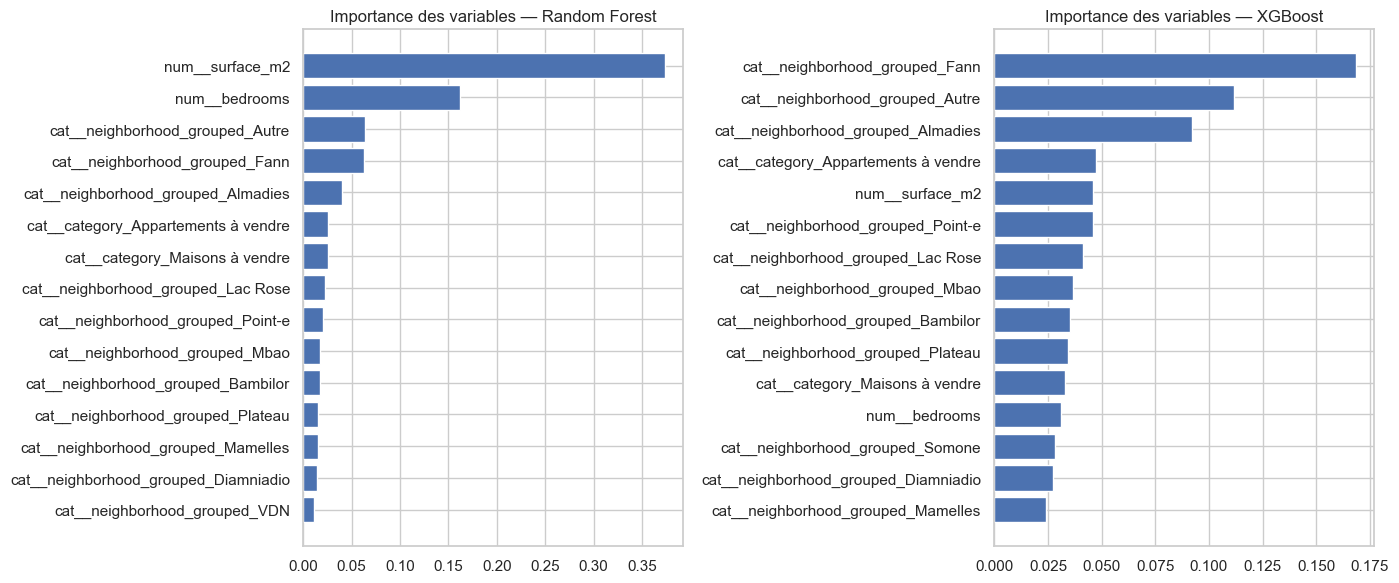

In [13]:
def get_feature_names(pipeline):
    return pipeline.named_steps["preprocessor"].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, estimator) in zip(axes, [("Random Forest", rf_best), ("XGBoost", xgb_best)]):
    feature_names = get_feature_names(estimator)
    importances = estimator.named_steps["model"].feature_importances_
    order = np.argsort(importances)[-15:]
    ax.barh(np.array(feature_names)[order], importances[order])
    ax.set_title(f"Importance des variables — {name}")

plt.tight_layout()
plt.show()


## Sauvegarde des modèles pour l'interface Streamlit


In [14]:
if os.path.isdir("data"):
    model_dir = "models"          # exécuté depuis la racine du projet
elif os.path.isdir("../data"):
    model_dir = "../models"       # exécuté depuis notebooks/
else:
    model_dir = "models"          # ex. Colab : pas de structure de dossiers locale
os.makedirs(model_dir, exist_ok=True)

fitted_pipelines = {
    "linear_regression": lr_pipeline,
    "random_forest": rf_best,
    "xgboost": xgb_best,
    "mlp": mlp_best,
}

for name, pipeline in fitted_pipelines.items():
    joblib.dump(pipeline, os.path.join(model_dir, f"{name}.joblib"))

best_model_name = results_df["MAE_FCFA"].idxmin()
reverse_lookup = {
    "Régression linéaire": "linear_regression",
    "Random Forest (optimisé)": "random_forest",
    "XGBoost (optimisé)": "xgboost",
    "MLP (optimisé)": "mlp",
}
best_model_key = reverse_lookup[best_model_name]

metadata = {
    "features": {
        "numeric": NUMERIC_FEATURES,
        "categorical": CATEGORICAL_FEATURES,
    },
    "categories": sorted(df["category"].unique().tolist()),
    "neighborhoods": sorted(df["neighborhood_grouped"].unique().tolist()),
    "surface_m2_range": [float(df["surface_m2"].min()), float(df["surface_m2"].max())],
    "bedrooms_range": [int(df["bedrooms"].min()), int(df["bedrooms"].max())],
    "best_model": best_model_key,
    "model_files": {k: f"{k}.joblib" for k in fitted_pipelines},
    "results": results,
}

with open(os.path.join(model_dir, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Modèles et métadonnées sauvegardés dans {model_dir}/")
print(f"Meilleur modèle (MAE la plus basse) : {best_model_name}")


Modèles et métadonnées sauvegardés dans ../models/
Meilleur modèle (MAE la plus basse) : Random Forest (optimisé)


### Constats principaux (à reprendre dans le rapport, section 5.2 / Discussion)

- L'optimisation des hyperparamètres améliore les modèles à base d'arbres (Random Forest, XGBoost) par rapport à leurs versions par défaut — quantifier ce gain dans le rapport en comparant avec/sans `RandomizedSearchCV` si le temps le permet.
- Sur un dataset de cette taille (~600 lignes), le MLP n'a généralement pas d'avantage net sur les modèles à base d'arbres — un résultat en soi intéressant à discuter (les réseaux de neurones ont besoin de plus de données pour exprimer leur avantage), plutôt qu'un échec à corriger.
- La surface reste la variable la plus importante, suivie du quartier — cohérent avec la littérature en évaluation immobilière (modèles hédoniques).
